In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("tayara_cars.csv")
print(df.shape)


(10730, 12)


In [6]:
%pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


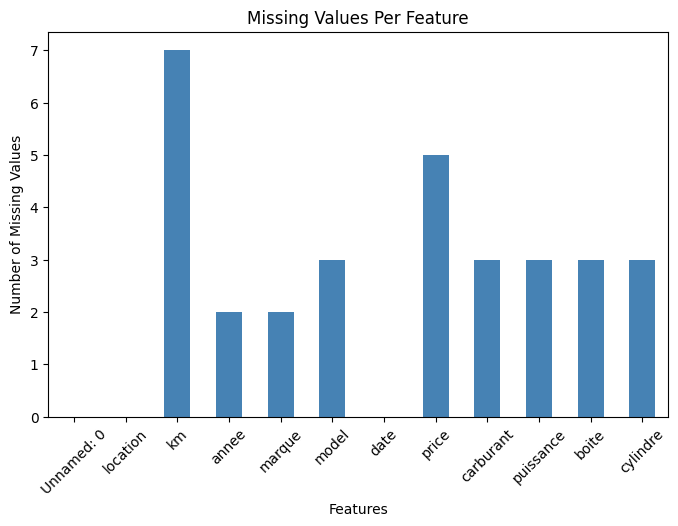

In [7]:
import pandas as pd
import matplotlib.pyplot as plt


missing = df.isnull().sum()

plt.figure(figsize=(8,5))
missing.plot(kind='bar', color='steelblue')
plt.title("Missing Values Per Feature")
plt.ylabel("Number of Missing Values")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.show()

In [8]:
display(df.head())

,Unnamed: 0,location,km,annee,marque,model,date,price,carburant,puissance,boite,cylindre
0,0,"Ben arous, Ezzahra",1.0,2021,Volkswagen,Polo,14 mars 2021,12500.0,Diesel,4,Jaune,Compacte
1,1,"Tunis, Tunis",180000.0,2008,Opel,Astra,14 mars 2021,21500.0,Diesel,1,Noir,Berline
2,2,"Ben arous, Ezzahra",1.0,2021,Volkswagen,Polo,14 mars 2021,12500.0,Diesel,4,Jaune,Compacte
3,3,"Tunis, Tunis",180000.0,2008,Opel,Astra,14 mars 2021,21500.0,Diesel,1,Noir,Berline
4,4,"Monastir, Autres villes",200000.0,1999,Renault,12,14 mars 2021,111111.0,Essence,4,Blanc,Autres


In [9]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10730 entries, 0 to 10729
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  10730 non-null  int64  
 1   location    10730 non-null  str    
 2   km          10723 non-null  float64
 3   annee       10728 non-null  str    
 4   marque      10728 non-null  str    
 5   model       10727 non-null  str    
 6   date        10730 non-null  str    
 7   price       10725 non-null  float64
 8   carburant   10727 non-null  str    
 9   puissance   10727 non-null  str    
 10  boite       10727 non-null  str    
 11  cylindre    10727 non-null  str    
dtypes: float64(2), int64(1), str(9)
memory usage: 1006.1 KB


None

In [10]:
# drop the "Unnamed: 0" column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

In [11]:
df = df.drop_duplicates()
print("After drop_duplicates:", df.shape)

After drop_duplicates: (10719, 11)


In [12]:
def to_number(series):
    s = series.astype(str).str.replace(r"[^\d.]", "", regex=True)
    s = s.replace("", np.nan)
    return pd.to_numeric(s, errors="coerce")
for col in ["price", "km", "annee", "puissance"]:
    if col in df.columns:
        df[col] = to_number(df[col])

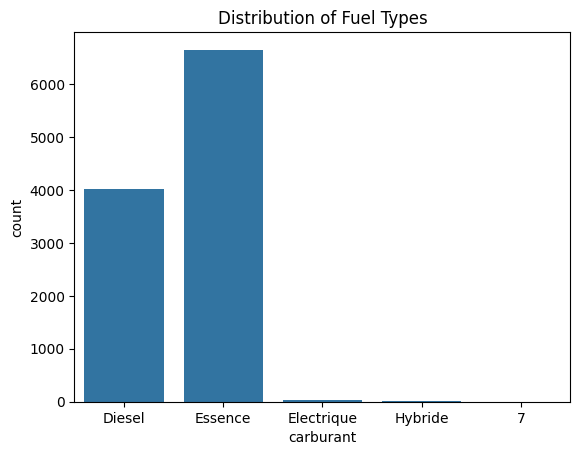

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="carburant")
plt.title("Distribution of Fuel Types")
plt.show()

In [14]:
print(df.dtypes)

location         str
km           float64
annee        float64
marque           str
model            str
date             str
price        float64
carburant        str
puissance    float64
boite            str
cylindre         str
dtype: object


In [15]:
# split "location" into "region" and "city"
if "location" in df.columns:
    loc_parts = df["location"].astype(str).str.split(",", n=1, expand=True)
    df["region"] = loc_parts[0].str.strip()
    df["city"]   = loc_parts[1].str.strip() if loc_parts.shape[1] > 1 else np.nan

In [16]:
# clean categorical columns
cat_cols = ["carburant", "boite", "cylindre", "color", "marque", "model"]
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": np.nan, "None": np.nan})

In [17]:
if "price" in df.columns:
    df = df.dropna(subset=["price"])
print("After cleaning:", df.shape)

After cleaning: (10714, 13)


In [18]:
for col in ["km", "annee", "puissance"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

In [19]:
for col in ["carburant", "boite", "cylindre", "region", "city", "marque", "model"]:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")

In [20]:
if "price" in df.columns:
    df = df[(df["price"] > 1000) & (df["price"] < 300000)]

if "km" in df.columns:
    df = df[(df["km"] >= 0) & (df["km"] < 700000)]

if "annee" in df.columns:
    df = df[(df["annee"] >= 1970) & (df["annee"] <= 2026)]

In [21]:
display(df.shape)
print(df.isna().mean().sort_values(ascending=False).head(10))
display(df.describe(include="all").T.head(15))

(7961, 13)

location     0.0
km           0.0
annee        0.0
marque       0.0
model        0.0
date         0.0
price        0.0
carburant    0.0
puissance    0.0
boite        0.0
dtype: float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
location,7961,299,"Tunis, Autres villes",1549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
km,7961.0,NaN,NaN,NaN,121652.832307,116998.863352,0.0,300.0,107000.0,199000.0,680000.0
annee,7961.0,NaN,NaN,NaN,2007.537621,8.683353,1975.0,2002.0,2010.0,2014.0,2021.0
marque,7961,56,Volkswagen,1164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,7961,486,Polo,401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,7961,37,13 mars 2021,667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,7961.0,NaN,NaN,NaN,28709.406356,23105.636234,1100.0,14500.0,23500.0,35000.0,200000.0
carburant,7961,6,Essence,5129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
puissance,7961.0,NaN,NaN,NaN,1082618.980656,42317180.357261,0.0,5.0,5.0,7.0,2147483647.0
boite,7961,33,Blanc,1868,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
df.to_csv("tayara_cars_clean.csv", index=False)
print("Saved: tayara_cars_clean.csv")
p = df.copy()
display(p.head())

,location,km,annee,marque,model,date,price,carburant,puissance,boite,cylindre,region,city
0,"Ben arous, Ezzahra",1.0,2021.0,Volkswagen,Polo,14 mars 2021,12500.0,Diesel,4.0,Jaune,Compacte,Ben arous,Ezzahra
1,"Tunis, Tunis",180000.0,2008.0,Opel,Astra,14 mars 2021,21500.0,Diesel,1.0,Noir,Berline,Tunis,Tunis
2,"Monastir, Autres villes",200000.0,1999.0,Renault,12,14 mars 2021,111111.0,Essence,4.0,Blanc,Autres,Monastir,Autres villes
3,"Tunis, Autres villes",29000.0,2019.0,Volkswagen,Polo,14 mars 2021,45000.0,Essence,5.0,Nouveau,Manuelle,Tunis,Autres villes
4,"Tunis, Autres villes",122.0,2013.0,Peugeot,208,13 mars 2021,26800.0,Essence,5.0,Marron,Compacte,Tunis,Autres villes


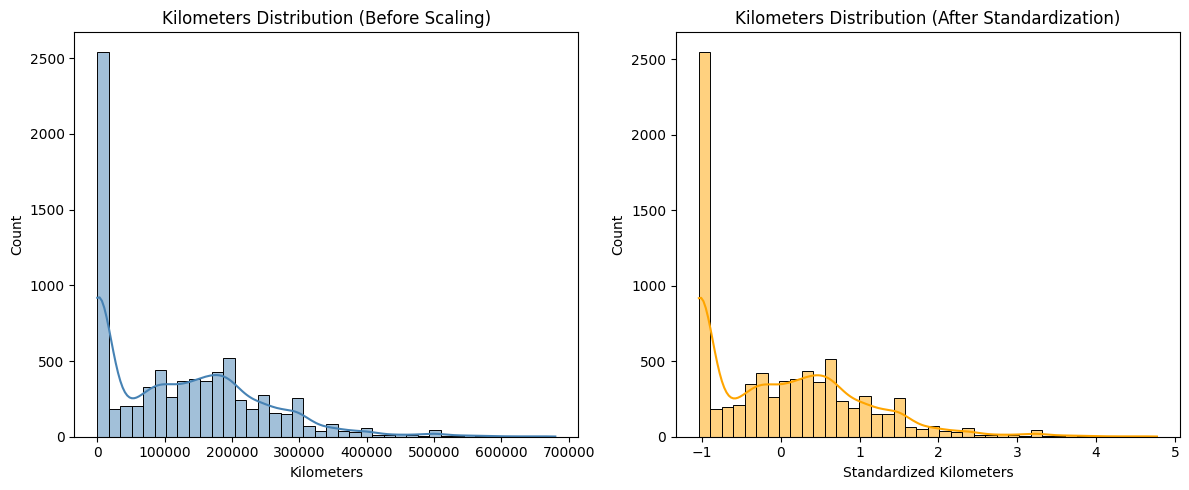

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Create a copy
df_scaled = p.copy()

# Apply StandardScaler
scaler = StandardScaler()
df_scaled["km_scaled"] = scaler.fit_transform(p[["km"]])

# Plot before and after
plt.figure(figsize=(12,5))

# Before scaling
plt.subplot(1,2,1)
sns.histplot(p["km"], bins=40, kde=True, color="steelblue")
plt.title("Kilometers Distribution (Before Scaling)")
plt.xlabel("Kilometers")

# After scaling
plt.subplot(1,2,2)
sns.histplot(df_scaled["km_scaled"], bins=40, kde=True, color="orange")
plt.title("Kilometers Distribution (After Standardization)")
plt.xlabel("Standardized Kilometers")

plt.tight_layout()
plt.show()

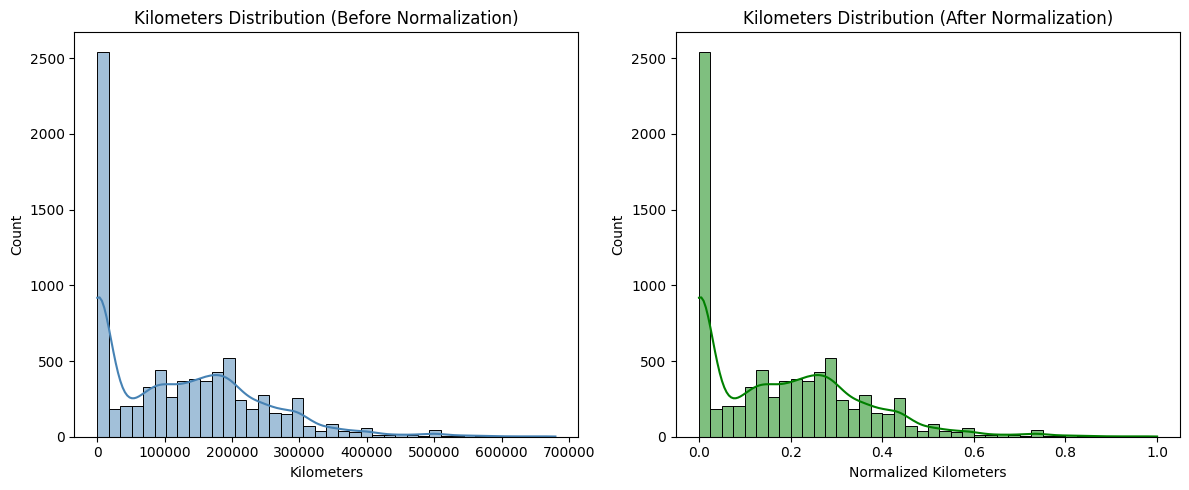

In [24]:
plt.figure(figsize=(12,5))
from sklearn.preprocessing import MinMaxScaler

df_norm = df.copy()

scaler = MinMaxScaler()
df_norm["km_norm"] = scaler.fit_transform(df[["km"]])
# Before normalization
plt.subplot(1,2,1)
sns.histplot(p["km"], bins=40, kde=True, color="steelblue")
plt.title("Kilometers Distribution (Before Normalization)")
plt.xlabel("Kilometers")

# After normalization
plt.subplot(1,2,2)
sns.histplot(df_norm["km_norm"], bins=40, kde=True, color="green")
plt.title("Kilometers Distribution (After Normalization)")
plt.xlabel("Normalized Kilometers")

plt.tight_layout()
plt.show()

<Axes: xlabel='km', ylabel='Count'>

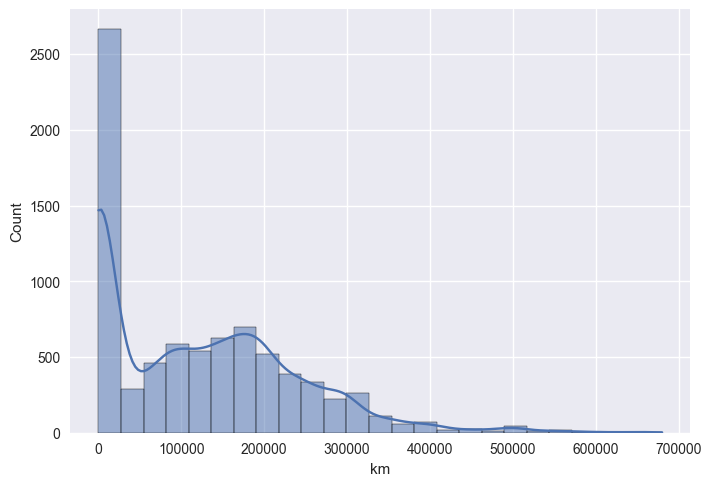

In [25]:
plt.style.use("seaborn-v0_8")

sns.histplot(df["km"], bins=25, kde=True)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["km_scaled"] = scaler.fit_transform(df[["km"]])

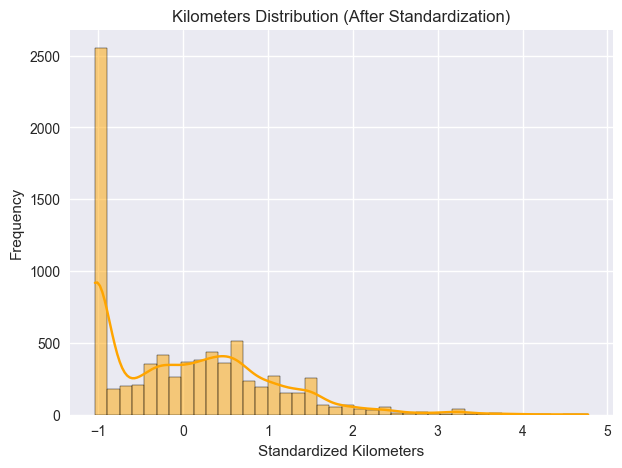

In [27]:
plt.figure(figsize=(7,5))

sns.histplot(df["km_scaled"], bins=40, kde=True, color="orange")

plt.title("Kilometers Distribution (After Standardization)")
plt.xlabel("Standardized Kilometers")
plt.ylabel("Frequency")

plt.show()

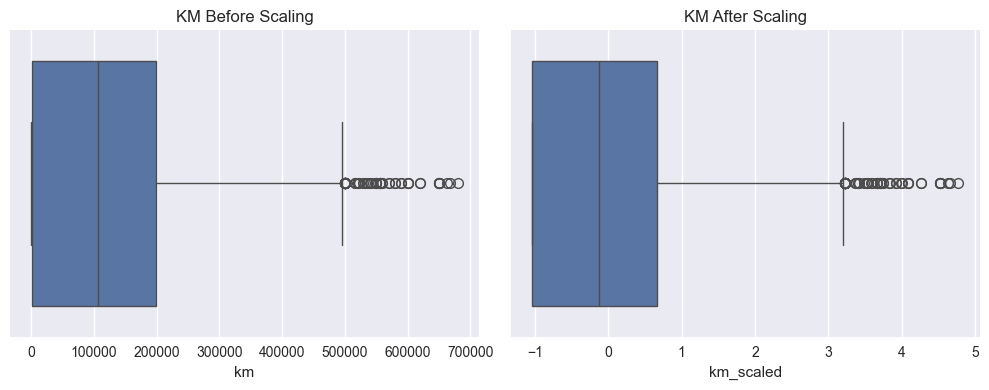

In [28]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df["km"])
plt.title("KM Before Scaling")

plt.subplot(1,2,2)
sns.boxplot(x=df["km_scaled"])
plt.title("KM After Scaling")

plt.tight_layout()
plt.show()

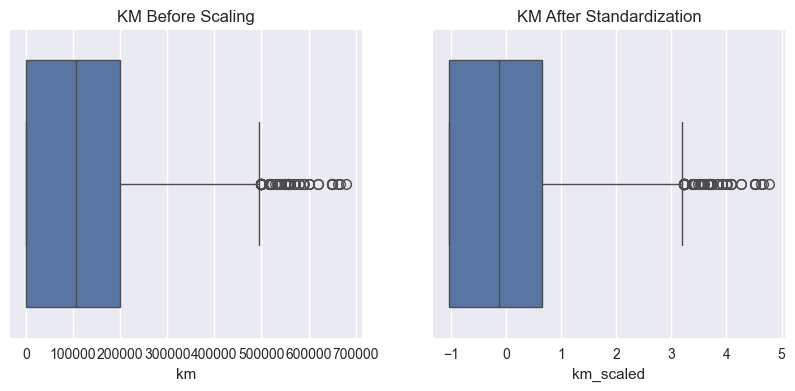

In [29]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df["km"])
plt.title("KM Before Scaling")

plt.subplot(1,2,2)
sns.boxplot(x=df["km_scaled"])
plt.title("KM After Standardization")

plt.show()

In [30]:
from sklearn.preprocessing import MinMaxScaler

# Create a copy
df_norm = df.copy()

# Apply MinMax normalization
scaler = MinMaxScaler()
df_norm["km_norm"] = scaler.fit_transform(df[["km"]])

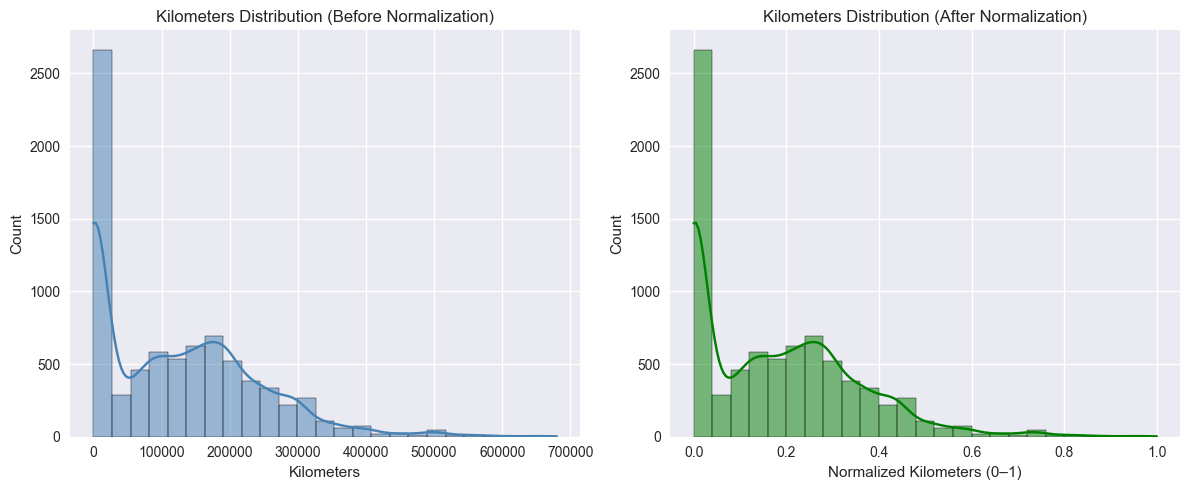

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Before normalization
plt.subplot(1,2,1)
sns.histplot(df["km"], bins=25, kde=True, color="steelblue")
plt.title("Kilometers Distribution (Before Normalization)")
plt.xlabel("Kilometers")

# After normalization
plt.subplot(1,2,2)
sns.histplot(df_norm["km_norm"], bins=25, kde=True, color="green")
plt.title("Kilometers Distribution (After Normalization)")
plt.xlabel("Normalized Kilometers (0–1)")

plt.tight_layout()
plt.show()

In [36]:
numeric_features = [col for col in ["km", "annee", "puissance"] if col in df.columns]

if numeric_features:
    df_standard = df.copy()
    for col in numeric_features:
        std = df_standard[col].std()
        if std and not np.isclose(std, 0):
            df_standard[col] = (df_standard[col] - df_standard[col].mean()) / std
        else:
            df_standard[col] = 0

    plt.figure(figsize=(5 * len(numeric_features), 4))

    for i, col in enumerate(numeric_features):
        plt.subplot(1, len(numeric_features), i + 1)
        sns.histplot(df_standard[col].dropna(), bins=30, kde=True)
        plt.title(f"Standardized {col}")
        plt.xlabel(col)

    plt.tight_layout()
    plt.show()
else:
    print("No numeric features available for standardization.")

NameError: name 'features' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
from sklearn.model_selection import train_test_split

# Features (X) and target (y)
X = p.drop("price", axis=1)   # input variables
y = p["price"]                # target variable

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # ensures reproducibility
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (6368, 12)
Testing set size: (1593, 12)


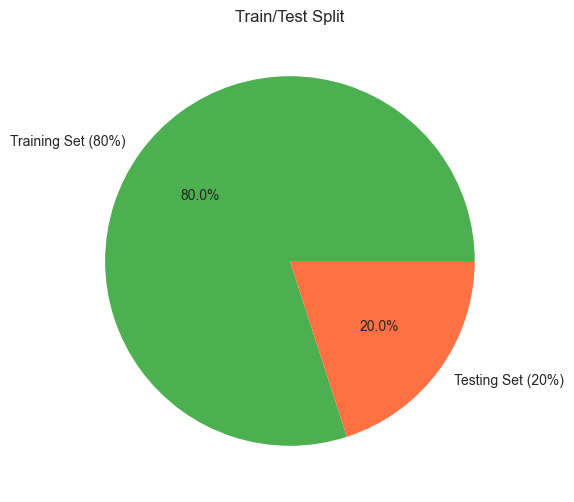

In [ ]:
import matplotlib.pyplot as plt

sizes = [len(X_train), len(X_test)]
labels = ['Training Set (80%)', 'Testing Set (20%)']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#4CAF50','#FF7043'])
plt.title("Train/Test Split")
plt.show()

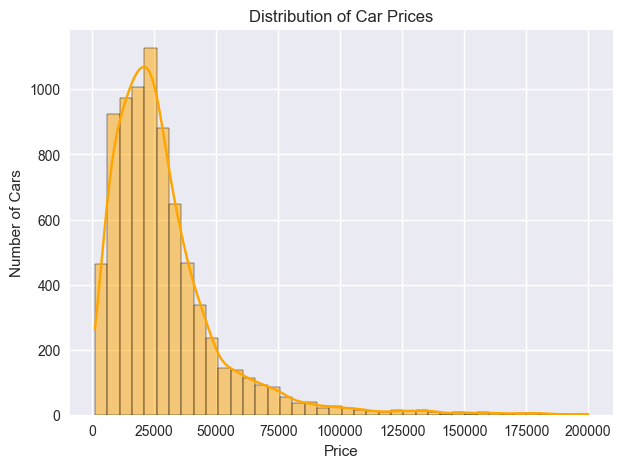

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

sns.histplot(p["price"], bins=40, kde=True, color="orange")

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")

plt.show()

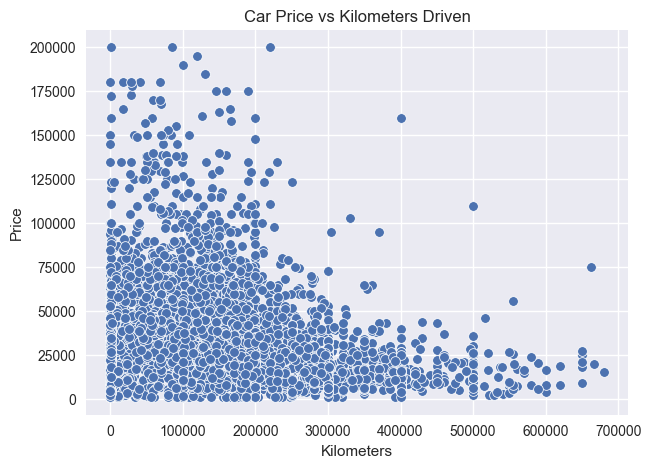

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(x="km", y="price", data=p)

plt.title("Car Price vs Kilometers Driven")
plt.xlabel("Kilometers")
plt.ylabel("Price")

plt.show()

In [ ]:
p = p[p["carburant"].isin(["Diesel","Essence","Hybride","Electrique"])]

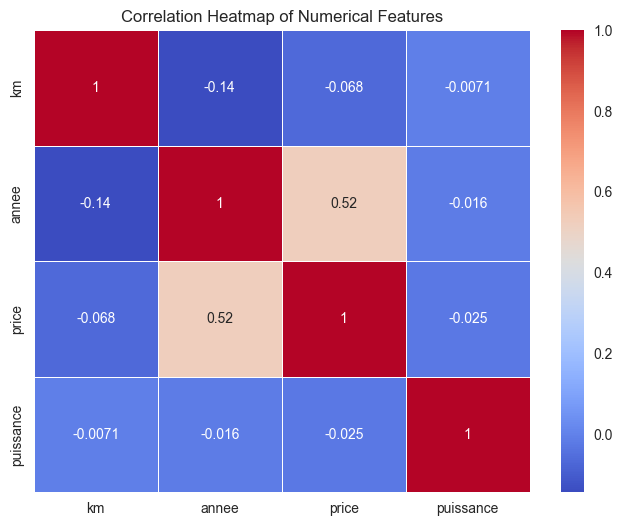

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
corr = p.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1) Use your dataframe (df or p)
data = p.copy()   # change to df.copy() if your df is named df

# 2) Drop rows with missing target
data = data.dropna(subset=["price"])

# 3) Split features/target
X = data.drop("price", axis=1)
y = data["price"]

# 4) One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# 5) Drop rows with any missing values in features
X = X.dropna()
y = y.loc[X.index]   # keep y aligned with X

# 6) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7) Train + evaluate
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 8070.5234207104595
R2 Score: 0.6259800520700683


In [ ]:
print(X_train.dtypes.head())
print("Any NaN in X_train?", X_train.isna().any().any())
print("Any NaN in y_train?", y_train.isna().any())

km                                float64
annee                             float64
puissance                         float64
location_Ariana, Ariana Ville        bool
location_Ariana, Autres villes       bool
dtype: object
Any NaN in X_train? False
Any NaN in y_train? False


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Use your dataframe name (df or p)
data = p.copy()   # change to df.copy() if your dataframe is df

# Drop missing target
data = data.dropna(subset=["price"])

# Split features/target
X = data.drop("price", axis=1)
y = data["price"]

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Handle possible NaN in X (after numeric conversion)
X = X.dropna()
y = y.loc[X.index]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest model
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Random Forest Results
MAE: 5840.048279974891
RMSE: 12882.549294021906
R2: 0.7087706886114464


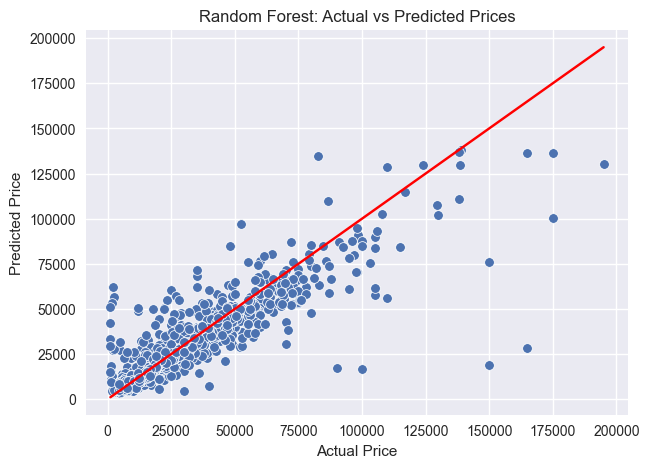

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred)

# perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Random Forest: Actual vs Predicted Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

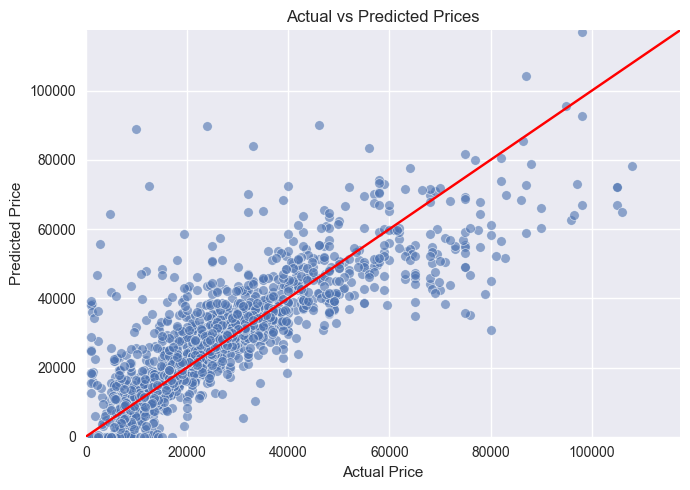

MAE: 8083.756846059215
R2 Score: 0.5961168514492199


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

if "y_test" not in globals() or "y_pred" not in globals():
    data = p.copy()
    data = data.dropna(subset=["price"])

    X = data.drop("price", axis=1)
    y = data["price"]

    X = pd.get_dummies(X, drop_first=True)
    X = X.dropna()
    y = y.loc[X.index]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

actual = np.asarray(y_test)
predicted = np.clip(np.asarray(y_pred), 0, None)

combined = np.concatenate([actual, predicted])
lower = max(0, np.percentile(combined, 1))
upper = np.percentile(combined, 99)

plt.figure(figsize=(7,5))
sns.scatterplot(x=actual, y=predicted, alpha=0.6)
plt.plot([lower, upper], [lower, upper], color="red")
plt.xlim(lower, upper)
plt.ylim(lower, upper)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.tight_layout()
plt.show()

print("MAE:", mean_absolute_error(actual, predicted))
print("R2 Score:", r2_score(actual, predicted))

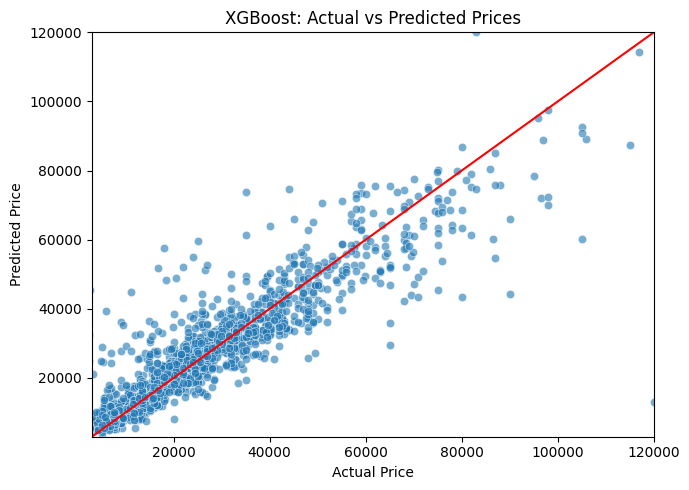

MAE: 6030.109297451251
R2 Score: 0.7152917672854358


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    data = pd.read_csv("tayara_cars_clean.csv")
except FileNotFoundError:
    if "p" in globals():
        data = p.copy()
    elif "df" in globals():
        data = df.copy()
    else:
        raise FileNotFoundError("tayara_cars_clean.csv was not found. Run the cleaning cells first.")

data = data.dropna(subset=["price"])

X = data.drop("price", axis=1)
y = data["price"]

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "regressor",
            XGBRegressor(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

actual = y_test.to_numpy()
predicted = np.clip(y_pred, 0, None)
combined = np.concatenate([actual, predicted])
lower = max(0, np.percentile(combined, 1))
upper = np.percentile(combined, 99)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=actual, y=predicted, alpha=0.6)
plt.plot([lower, upper], [lower, upper], color="red")
plt.xlim(lower, upper)
plt.ylim(lower, upper)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()

print("MAE:", mean_absolute_error(actual, y_pred))
print("R2 Score:", r2_score(actual, y_pred))

,Model,MAE,R2,Best Params
0,Random Forest,5834.757967,0.709717,"{'regressor__max_depth': None, 'regressor__min..."
1,XGBoost,6293.336513,0.706138,"{'regressor__colsample_bytree': 0.8, 'regresso..."
2,Linear Regression,15818.784260,0.004076,{}


Best model by R2: Random Forest
Best R2: 0.7097167130572781
Best MAE: 5834.757967147939


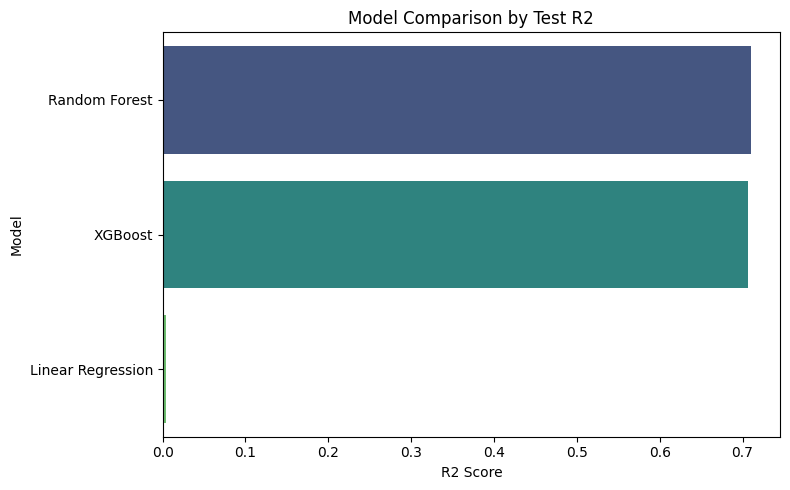

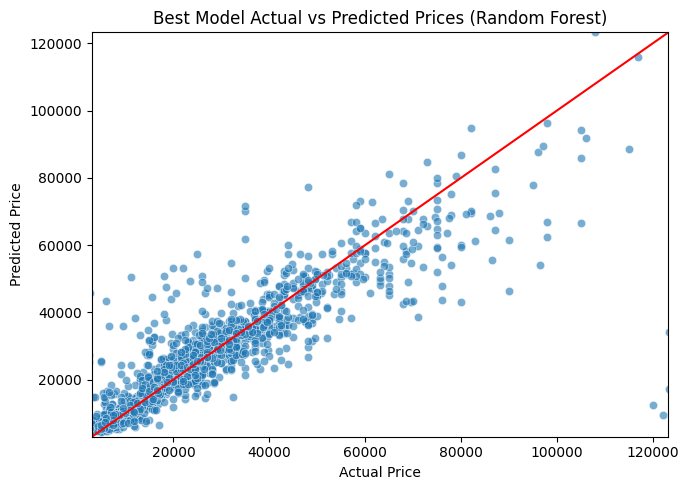

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    data = pd.read_csv("tayara_cars_clean.csv")
except FileNotFoundError:
    if "p" in globals():
        data = p.copy()
    elif "df" in globals():
        data = df.copy()
    else:
        raise FileNotFoundError("tayara_cars_clean.csv was not found. Run the cleaning cells first.")

data = data.dropna(subset=["price"])

X = data.drop("price", axis=1)
y = data["price"]

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "Linear Regression": {
        "pipeline": Pipeline(
            steps=[
                ("preprocess", preprocess),
                ("regressor", LinearRegression()),
            ]
        ),
        "params": {},
    },
    "Random Forest": {
        "pipeline": Pipeline(
            steps=[
                ("preprocess", preprocess),
                ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1)),
            ]
        ),
        "params": {
            "regressor__n_estimators": [200],
            "regressor__max_depth": [None, 12],
            "regressor__min_samples_split": [2],
        },
    },
    "XGBoost": {
        "pipeline": Pipeline(
            steps=[
                ("preprocess", preprocess),
                (
                    "regressor",
                    XGBRegressor(
                        objective="reg:squarederror",
                        random_state=42,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "params": {
            "regressor__n_estimators": [200],
            "regressor__learning_rate": [0.05],
            "regressor__max_depth": [4, 6],
            "regressor__subsample": [0.8],
            "regressor__colsample_bytree": [0.8],
        },
    },
}

results = []
best_estimators = {}

for model_name, config in models.items():
    if config["params"]:
        search = GridSearchCV(
            estimator=config["pipeline"],
            param_grid=config["params"],
            cv=3,
            scoring="r2",
            n_jobs=-1,
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        best_params = search.best_params_
    else:
        best_model = config["pipeline"]
        best_model.fit(X_train, y_train)
        best_params = {}

    y_pred = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append(
        {
            "Model": model_name,
            "MAE": mae,
            "R2": r2,
            "Best Params": best_params,
        }
    )
    best_estimators[model_name] = best_model

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)

display(results_df)

best_row = results_df.iloc[0]
print("Best model by R2:", best_row["Model"])
print("Best R2:", best_row["R2"])
print("Best MAE:", best_row["MAE"])

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="R2", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Model Comparison by Test R2")
plt.xlabel("R2 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

best_model = best_estimators[best_row["Model"]]
final_pred = best_model.predict(X_test)
final_pred = np.clip(final_pred, 0, None)
actual = y_test.to_numpy()
combined = np.concatenate([actual, final_pred])
lower = max(0, np.percentile(combined, 1))
upper = np.percentile(combined, 99)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=actual, y=final_pred, alpha=0.6)
plt.plot([lower, upper], [lower, upper], color="red")
plt.xlim(lower, upper)
plt.ylim(lower, upper)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Best Model Actual vs Predicted Prices ({best_row['Model']})")
plt.tight_layout()
plt.show()

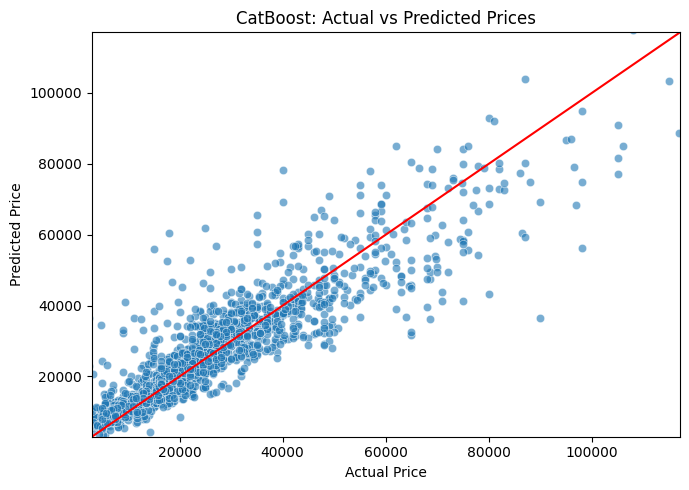

CatBoost MAE: 6611.339717227893
CatBoost R2 Score: 0.703700168530967


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

try:
    data = pd.read_csv("tayara_cars_clean.csv")
except FileNotFoundError:
    if "p" in globals():
        data = p.copy()
    elif "df" in globals():
        data = df.copy()
    else:
        raise FileNotFoundError("tayara_cars_clean.csv was not found. Run the cleaning cells first.")

data = data.dropna(subset=["price"])

X = data.drop("price", axis=1).copy()
y = data["price"]

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna("unknown").astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_feature_indices = [X.columns.get_loc(col) for col in categorical_cols]

model = CatBoostRegressor(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=0,
)

model.fit(X_train, y_train, cat_features=cat_feature_indices)
y_pred = model.predict(X_test)

actual = y_test.to_numpy()
predicted = np.clip(y_pred, 0, None)
combined = np.concatenate([actual, predicted])
lower = max(0, np.percentile(combined, 1))
upper = np.percentile(combined, 99)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=actual, y=predicted, alpha=0.6)
plt.plot([lower, upper], [lower, upper], color="red")
plt.xlim(lower, upper)
plt.ylim(lower, upper)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("CatBoost: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()

print("CatBoost MAE:", mean_absolute_error(actual, y_pred))
print("CatBoost R2 Score:", r2_score(actual, y_pred))